In [1]:
!pip install -q transformers peft datasets evaluate accelerate wandb

In [2]:
from __future__ import annotations

import time
import warnings
from dataclasses import dataclass, field
from typing import Callable

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datasets import load_dataset
from peft import LoraConfig, TaskType, get_peft_model
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainerCallback,
    TrainingArguments,
)
import evaluate as hf_evaluate
import wandb

warnings.filterwarnings("ignore")
SEED = 42
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# Number of virtual clients used to approximate per-client loss distribution
N_CLIENTS = 100

WANDB_PROJECT = "thesis-preliminary-h2-loss"
WANDB_ENTITY = "ilham-abdillah-alhamdi-universitas-indonesia"


Device: cuda


In [3]:
@dataclass
class LoRAConfig:
    r: int               = 8
    lora_alpha: int      = 16
    lora_dropout: float  = 0.05
    target_modules: list[str] = field(
        default_factory=lambda: ["Wqkv", "attn.Wo"]
    )
    bias: str = "none"


@dataclass
class TaskConfig:
    name: str
    hf_path: str
    hf_subset: str | None
    text_fields: list[str]
    label_field: str
    num_labels: int
    train_split: str     = "train"
    val_split: str       = "validation"
    model_name: str      = "answerdotai/ModernBERT-base"
    lora: LoRAConfig     = field(default_factory=LoRAConfig)
    learning_rate: float = 5e-4
    batch_size: int      = 32
    num_epochs: int      = 10

In [4]:
# CHOSEN_TASK = TaskConfig(
#     name        = "BoolQ (SuperGLUE)",
#     hf_path     = "super_glue",
#     hf_subset   = "boolq",
#     text_fields = ["passage", "question"],
#     label_field = "label",
#     num_labels  = 2,
#     num_epochs  = 5,
# )

CHOSEN_TASK = (
    TaskConfig(
        name="SST-2",
        hf_path="glue",
        hf_subset="sst2",
        text_fields=["sentence"],
        label_field="label",
        num_labels=2,
        num_epochs=10,
    )
)

In [5]:
def tokenize_dataset(cfg: TaskConfig, raw_ds):
    """Tokenise a HuggingFace dataset using cfg.text_fields."""
    tok = AutoTokenizer.from_pretrained(cfg.model_name)

    def _encode(examples):
        parts = [examples[f] for f in cfg.text_fields]
        return tok(*parts, truncation=True, max_length=512)

    if cfg.label_field != "labels":
        raw_ds = raw_ds.rename_column(cfg.label_field, "labels")

    drop = [c for c in raw_ds.column_names if c != "labels"]

    ds = raw_ds.map(_encode, batched=True, remove_columns=drop)
    ds.set_format("torch")
    return ds


def load_splits(cfg: TaskConfig):
    raw_train = load_dataset(cfg.hf_path, cfg.hf_subset, split=cfg.train_split)
    raw_val   = load_dataset(cfg.hf_path, cfg.hf_subset, split=cfg.val_split)
    print(f"  Train: {len(raw_train):,} | Val: {len(raw_val):,}")
    return tokenize_dataset(cfg, raw_train), tokenize_dataset(cfg, raw_val)

In [6]:
import math

def compute_steps_per_client(train_size: int,
                              n_clients: int,
                              batch_size: int) -> int:
    """
    Steps one virtual client takes to complete one local epoch on its shard.
    Setting logging_steps to this value means each logged loss =
    one client reporting its training loss after finishing a local round.

    """
    shard_size = train_size / n_clients
    return max(1, math.ceil(shard_size / batch_size))

In [7]:
@dataclass
class CvPoint:
    epoch:          float
    cv:             float
    mean_loss:      float
    std_loss:       float
    min_loss:       float
    max_loss:       float
    val_accuracy:   float | None = None
    n_clients_reported: int          = 0


class UtilityCvLogger(TrainerCallback):
    """
    After each epoch:
      1. Evaluates per-client loss CV on the training set.
      2. Records a CvPoint with full distribution statistics.
    """

    def __init__(self, n_clients: int = N_CLIENTS):
        self.n_clients        = n_clients
        self._client_losses: list[float] = []   # one entry per client per epoch
        self.history: list[CvPoint]      = []
        self._last_val_acc: float | None = None

    def on_epoch_begin(self, args, state, control, **kwargs):
        self._client_losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        # Each call here = one virtual client finished its local training.
        # The Trainer's "loss" at this point is the mean over the last
        # logging_steps steps = mean loss over that client's shard.
        if logs and "loss" in logs:
            self._client_losses.append(float(logs["loss"]))


    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            self._last_val_acc = next(
                (v for k, v in metrics.items()
                 if "loss" not in k and isinstance(v, float)),
                None
            )


    def on_epoch_end(self, args, state, control, model=None, **kwargs):
        if len(self._client_losses) < 2:
            return

        arr = np.array(self._client_losses)
        cv  = arr.std() / arr.mean() if arr.mean() > 0 else 0.0

        pt = CvPoint(
            epoch        = state.epoch or 0.0,
            cv           = cv,
            mean_loss    = float(arr.mean()),
            std_loss     = float(arr.std()),
            min_loss     = float(arr.min()),
            max_loss     = float(arr.max()),
            val_accuracy = self._last_val_acc,
            n_clients_reported = len(self._client_losses),
        )

        self.history.append(pt)

        wandb.log({
            "custom/cv": pt.cv,
            "custom/mean_loss": pt.mean_loss,
            "custom/std_loss": pt.std_loss,
            "custom/min_loss": pt.min_loss,
            "custom/max_loss": pt.max_loss,
            "epoch": pt.epoch
        }, step=state.global_step)

        print(f"    [CV] Epoch {pt.epoch:.0f} — "
              f"CV={cv:.4f}  mean_loss={pt.mean_loss:.4f}  "
              f"std={pt.std_loss:.4f}  "
              f"range=[{pt.min_loss:.4f}, {pt.max_loss:.4f}]")

In [8]:
def make_lora_model(cfg: TaskConfig,
                    random_init: bool = False) -> torch.nn.Module:
    """
    random_init=False → pretrained ModernBERT + LoRA (your FL setup)
    random_init=True  → randomly initialised full model (train-from-scratch
                         baseline; all params trainable, no LoRA)
    """
    if random_init:
        # Randomly initialised — represents standard FL without a pretrained
        # foundation model (training from scratch scenario)
        config = AutoConfig.from_pretrained(
            cfg.model_name,
            num_labels=cfg.num_labels,
        )
        model = AutoModelForSequenceClassification.from_config(config)
        trainable = sum(p.numel() for p in model.parameters())
        total     = trainable
        print(f"  [random-init full model] "
              f"Trainable: {trainable:,} / {total:,} (100.00%)")
    else:
        base = AutoModelForSequenceClassification.from_pretrained(
            cfg.model_name,
            num_labels=cfg.num_labels,
            ignore_mismatched_sizes=True,
            torch_dtype=torch.float32,
        )
        peft_cfg = LoraConfig(
            task_type      = TaskType.SEQ_CLS,
            r              = cfg.lora.r,
            lora_alpha     = cfg.lora.lora_alpha,
            lora_dropout   = cfg.lora.lora_dropout,
            target_modules = cfg.lora.target_modules,
            bias           = cfg.lora.bias,
        )
        model = get_peft_model(base, peft_cfg)
        trainable, total = model.get_nb_trainable_parameters()
        print(f"  [pretrained + LoRA] "
              f"Trainable: {trainable:,} / {total:,} "
              f"({100*trainable/total:.2f}%)")
    return model


def run_condition(
    cfg: TaskConfig,
    train_ds,
    val_ds,
    collator,
    condition_label: str,
    random_init: bool,
) -> UtilityCvLogger:
    print(f"\n  ── Condition: {condition_label} ──")

    wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=condition_label,
        reinit=True
    )

    steps_per_client = compute_steps_per_client(
        train_size = len(train_ds),
        n_clients  = N_CLIENTS,
        batch_size = cfg.batch_size,
    )


    model  = make_lora_model(cfg, random_init=random_init)
    cv_log = UtilityCvLogger(n_clients=N_CLIENTS)

    metric_fn = hf_evaluate.load("accuracy")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return metric_fn.compute(predictions=preds, references=labels)

    args = TrainingArguments(
        output_dir                  = f"/tmp/h2_{condition_label}",
        num_train_epochs            = cfg.num_epochs,
        per_device_train_batch_size = cfg.batch_size,
        per_device_eval_batch_size  = cfg.batch_size,
        learning_rate               = cfg.learning_rate,
        lr_scheduler_type           = "cosine",
        warmup_ratio                = 0.05,
        eval_strategy               = "epoch",
        save_strategy               = "no",
        logging_strategy            = "steps",
        logging_steps               = steps_per_client,
        report_to                   = "wandb",
        seed                        = SEED,
        gradient_checkpointing         = True,
        gradient_checkpointing_kwargs  = {"use_reentrant": False},
        fp16                        = (torch.cuda.is_available()
                                       and not random_init),
    )

    trainer = Trainer(
        model           = model,
        args            = args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        data_collator   = collator,
        compute_metrics = compute_metrics,
        callbacks       = [cv_log],
    )

    trainer.train()

    wandb.finish()

    return cv_log

In [9]:
cfg         = CHOSEN_TASK
train_ds, val_ds = load_splits(cfg)
tok         = AutoTokenizer.from_pretrained(cfg.model_name)
collator    = DataCollatorWithPadding(tokenizer=tok)

print(f"\nTask: {cfg.name}")
print(f"Virtual clients for CV: {N_CLIENTS}")

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

...

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

  Train: 67,349 | Val: 872


Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]


Task: SST-2
Virtual clients for CV: 100


In [10]:
# Condition B — full model from random init (train-from-scratch baseline)
cfg.batch_size = 32
log_random = run_condition(
    cfg, train_ds, val_ds, collator,
    condition_label="random_init_full",
    random_init=True,
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.



  ── Condition: random_init_full ──


wandb: Currently logged in as: ilham-abdillah-alhamdi (ilham-abdillah-alhamdi-universitas-indonesia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  [random-init full model] Trainable: 149,606,402 / 149,606,402 (100.00%)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.341000,0.465276,0.806193
2,0.244716,0.538666,0.816514


    [CV] Epoch 1 — CV=0.2332  mean_loss=0.4370  std=0.1019  range=[0.3158, 0.7892]
    [CV] Epoch 2 — CV=0.0740  mean_loss=0.2667  std=0.0197  range=[0.2171, 0.3202]


KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x728b041249e0>> (for post_run_cell), with arguments args (<ExecutionResult object at 728b04125730, execution_count=10 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 728b04125340, raw_cell="# Condition B — full model from random init (train.." transformed_cell="# Condition B — full model from random init (train.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bssh6.vast.ai/workspace/u-flora/preliminary/h2_utility_signal.ipynb#X12sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [ ]:
# Condition A — pretrained LoRA (your actual FL setup)
cfg.batch_size = 32
log_pretrained = run_condition(
    cfg, train_ds, val_ds, collator,
    condition_label="pretrained_lora",
    random_init=False,
)



  ── Condition: pretrained_lora ──


train/epoch,▁▂▃▄▄▅▆▇█
train/global_step,▁▂▃▄▅▅▆▇█
train/grad_norm,▆▃▂█▂▃▂▄▁
train/learning_rate,▁▂▃▄▄▅▆▇█
train/loss,▇▆▇▁▄▆▄█▆
train/epoch,0.12162
train/global_step,18
train/grad_norm,0.97596
train/learning_rate,0.00023
train/loss,0.70911


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [pretrained + LoRA] Trainable: 812,546 / 150,418,948 (0.54%)


...

Epoch,Training Loss,Validation Loss,Accuracy
1,0.619239,0.641816,0.643731
2,0.603110,0.510923,0.750153
3,0.339255,0.447678,0.798777
4,0.338409,0.465330,0.814067


    [CV] Epoch 1 — CV=0.0651  mean_loss=0.6635  std=0.0432  range=[0.5564, 0.8694]
    [CV] Epoch 2 — CV=0.1094  mean_loss=0.5677  std=0.0621  range=[0.4261, 0.7657]
    [CV] Epoch 3 — CV=0.1283  mean_loss=0.4314  std=0.0554  range=[0.3139, 0.5643]
    [CV] Epoch 4 — CV=0.1880  mean_loss=0.3036  std=0.0571  range=[0.1715, 0.4542]


Epoch,Training Loss,Validation Loss,Accuracy
1,0.619239,0.641816,0.643731
2,0.603110,0.510923,0.750153
3,0.339255,0.447678,0.798777
4,0.338409,0.465330,0.814067
5,0.242789,0.502352,0.810703


    [CV] Epoch 5 — CV=0.2727  mean_loss=0.2206  std=0.0602  range=[0.1098, 0.3570]


custom/cv,▁▂▃▅█
custom/max_loss,█▇▄▂▁
custom/mean_loss,█▆▄▂▁
custom/min_loss,█▆▄▂▁
custom/std_loss,▁█▆▆▇
epoch,▁▃▅▆█
eval/accuracy,▁▅▇██
eval/loss,█▃▁▂▃
eval/runtime,█▂▁▁▁
eval/samples_per_second,▁▇███
+6,...


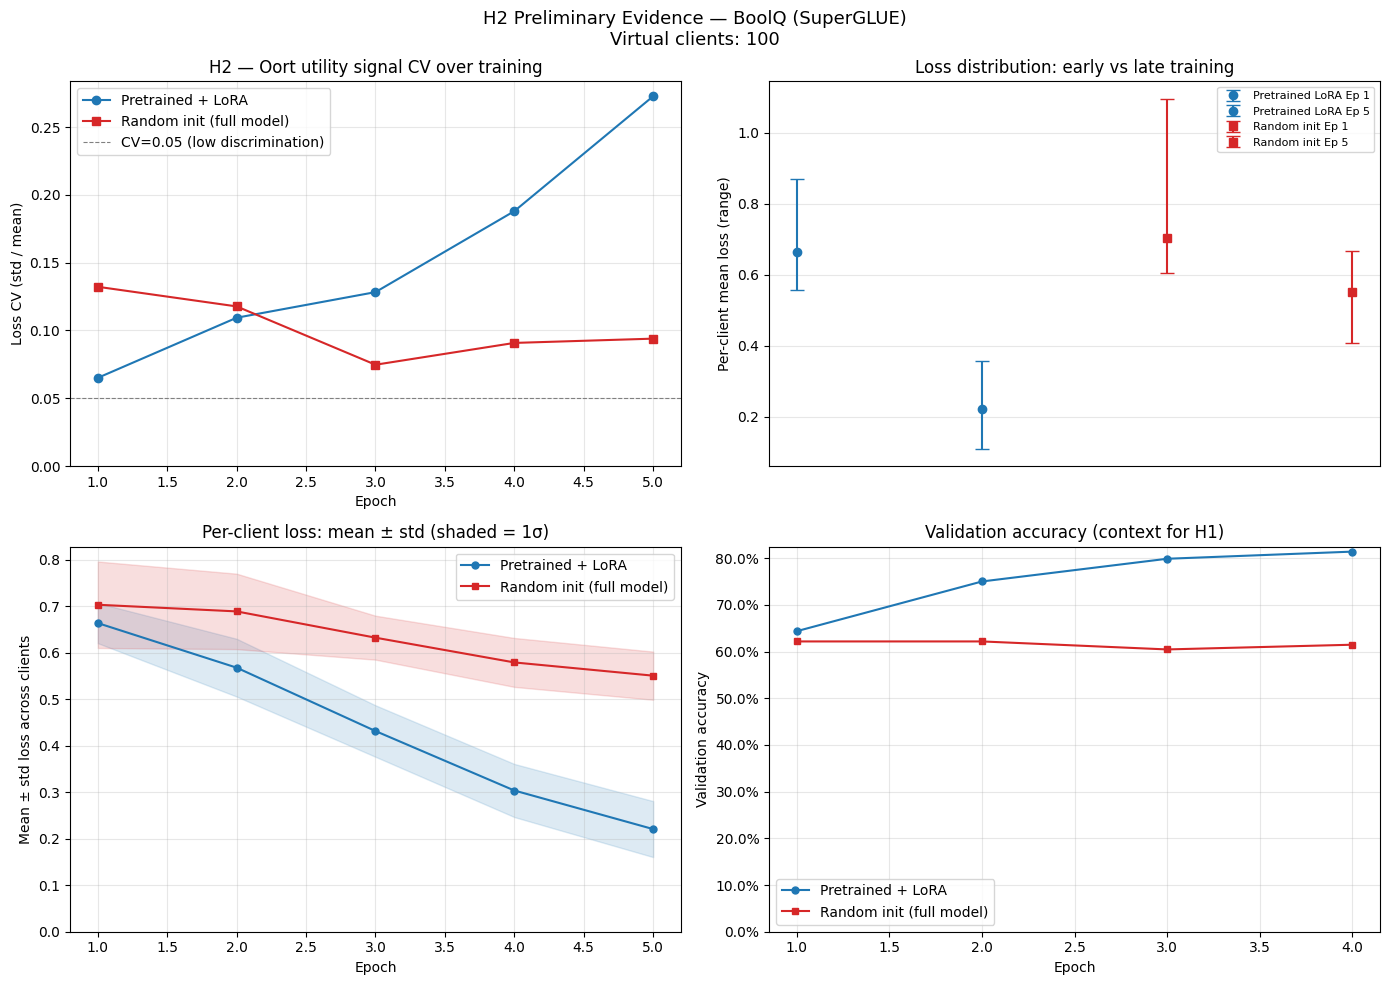


── H2 summary ─────────────────────────────────────────────────
Epoch       CV (pretrained)   CV (random init)    Ratio
────────────────────────────────────────────────────────
1                    0.0651             0.1322     2.03x
2                    0.1094             0.1178     1.08x
3                    0.1283             0.0748     0.58x
4                    0.1880             0.0908     0.48x
5                    0.2727             0.0940     0.34x

  At epoch 1: random-init CV is 2.0x higher than pretrained.
  H2: SUPPORTED (>2x)

  Pretrained  crosses CV<0.05 at epoch: None
  Random init crosses CV<0.05 at epoch: None


In [ ]:
def plot_h2(log_pt: UtilityCvLogger, log_rnd: UtilityCvLogger,
            task_name: str, figsize=(14, 10)):
    """
    Four-panel figure:
      Row 1 — CV over epochs + loss distribution box plots
      Row 2 — Mean loss over epochs + val accuracy over epochs
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    (ax_cv, ax_box), (ax_loss, ax_acc) = axes

    col_pt  = "#1f77b4"  # blue  — pretrained LoRA
    col_rnd = "#d62728"  # red   — random init

    ep_pt  = [p.epoch for p in log_pt.history]
    ep_rnd = [p.epoch for p in log_rnd.history]

    # ── CV vs epoch ───────────────────────────────────────────────────────────
    ax_cv.plot(ep_pt,  [p.cv for p in log_pt.history],
               "o-", color=col_pt,  ms=6, label="Pretrained + LoRA")
    ax_cv.plot(ep_rnd, [p.cv for p in log_rnd.history],
               "s-", color=col_rnd, ms=6, label="Random init (full model)")
    ax_cv.axhline(0.05, color="gray", ls="--", lw=0.8,
                  label="CV=0.05 (low discrimination)")
    ax_cv.set_xlabel("Epoch"); ax_cv.set_ylabel("Loss CV (std / mean)")
    ax_cv.set_title("H2 — Oort utility signal CV over training")
    ax_cv.legend(); ax_cv.grid(True, alpha=0.3); ax_cv.set_ylim(bottom=0)

    # ── Loss range box plot at epoch 1 and final epoch ────────────────────────
    def get_client_losses_at_epoch(log, target_epoch):
        # Re-compute is not stored per-client; approximate with range bars
        pt = min(log.history, key=lambda p: abs(p.epoch - target_epoch))
        return pt.mean_loss, pt.std_loss, pt.min_loss, pt.max_loss

    for ep_target, offset, label, col in [
        (1.0, -0.2, "Ep 1", col_pt),
        (min(len(log_pt.history), 10), 0.2, f"Ep {len(log_pt.history)}", col_pt),
    ]:
        m, s, lo, hi = get_client_losses_at_epoch(log_pt, ep_target)
        ax_box.errorbar(offset, m, yerr=[[m-lo], [hi-m]],
                        fmt="o", color=col, capsize=5,
                        label=f"Pretrained LoRA {label}")
    for ep_target, offset, label, col in [
        (1.0, 0.6, "Ep 1", col_rnd),
        (min(len(log_rnd.history), 10), 1.0, f"Ep {len(log_rnd.history)}", col_rnd),
    ]:
        m, s, lo, hi = get_client_losses_at_epoch(log_rnd, ep_target)
        ax_box.errorbar(offset, m, yerr=[[m-lo], [hi-m]],
                        fmt="s", color=col, capsize=5,
                        label=f"Random init {label}")
    ax_box.set_ylabel("Per-client mean loss (range)")
    ax_box.set_title("Loss distribution: early vs late training")
    ax_box.set_xticks([]); ax_box.legend(fontsize=8); ax_box.grid(True, alpha=0.3)

    # ── Mean loss vs epoch ────────────────────────────────────────────────────
    ax_loss.plot(ep_pt,  [p.mean_loss for p in log_pt.history],
                 "o-", color=col_pt,  ms=5, label="Pretrained + LoRA")
    ax_loss.plot(ep_rnd, [p.mean_loss for p in log_rnd.history],
                 "s-", color=col_rnd, ms=5, label="Random init (full model)")
    ax_loss.fill_between(
        ep_pt,
        [p.mean_loss - p.std_loss for p in log_pt.history],
        [p.mean_loss + p.std_loss for p in log_pt.history],
        alpha=0.15, color=col_pt,
    )
    ax_loss.fill_between(
        ep_rnd,
        [p.mean_loss - p.std_loss for p in log_rnd.history],
        [p.mean_loss + p.std_loss for p in log_rnd.history],
        alpha=0.15, color=col_rnd,
    )
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Mean ± std loss across clients")
    ax_loss.set_title("Per-client loss: mean ± std (shaded = 1σ)")
    ax_loss.legend(); ax_loss.grid(True, alpha=0.3); ax_loss.set_ylim(bottom=0)

    # ── Val accuracy vs epoch ─────────────────────────────────────────────────
    acc_pt  = [p.val_accuracy for p in log_pt.history
               if p.val_accuracy is not None]
    acc_rnd = [p.val_accuracy for p in log_rnd.history
               if p.val_accuracy is not None]
    ax_acc.plot(ep_pt[:len(acc_pt)],   acc_pt,
                "o-", color=col_pt,  ms=5, label="Pretrained + LoRA")
    ax_acc.plot(ep_rnd[:len(acc_rnd)], acc_rnd,
                "s-", color=col_rnd, ms=5, label="Random init (full model)")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Validation accuracy")
    ax_acc.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=1))
    ax_acc.set_title("Validation accuracy (context for H1)")
    ax_acc.legend(); ax_acc.grid(True, alpha=0.3); ax_acc.set_ylim(bottom=0)

    fig.suptitle(
        f"H2 Preliminary Evidence — {task_name}\n"
        f"Virtual clients: {N_CLIENTS}",
        fontsize=13
    )
    plt.tight_layout()
    plt.savefig("nb2_h2_utility_signal.png", dpi=150, bbox_inches="tight")
    plt.show()


def print_h2_summary(log_pt: UtilityCvLogger, log_rnd: UtilityCvLogger):
    print("\n── H2 summary ─────────────────────────────────────────────────")
    print(f"{'Epoch':<8} {'CV (pretrained)':>18} {'CV (random init)':>18} {'Ratio':>8}")
    print("─" * 56)
    for pt, rnd in zip(log_pt.history, log_rnd.history):
        ratio = rnd.cv / pt.cv if pt.cv > 0 else float("inf")
        print(f"{pt.epoch:<8.0f} {pt.cv:>18.4f} {rnd.cv:>18.4f} {ratio:>8.2f}x")
    print()

    ep1_pt  = log_pt.history[0].cv  if log_pt.history  else None
    ep1_rnd = log_rnd.history[0].cv if log_rnd.history else None
    if ep1_pt and ep1_rnd:
        ratio = ep1_rnd / ep1_pt
        print(f"  At epoch 1: random-init CV is {ratio:.1f}x higher than pretrained.")
        verdict = (
            "SUPPORTED (>2x)"     if ratio > 2.0 else
            "WEAKLY SUPPORTED"    if ratio > 1.3 else
            "NOT SUPPORTED"
        )
        print(f"  H2: {verdict}")

    pt_below = next(
        (p.epoch for p in log_pt.history  if p.cv < 0.05), None
    )
    rnd_below = next(
        (p.epoch for p in log_rnd.history if p.cv < 0.05), None
    )
    print(f"\n  Pretrained  crosses CV<0.05 at epoch: {pt_below}")
    print(f"  Random init crosses CV<0.05 at epoch: {rnd_below}")


plot_h2(log_pretrained, log_random, cfg.name)
print_h2_summary(log_pretrained, log_random)
